First 5 rows:
    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeI

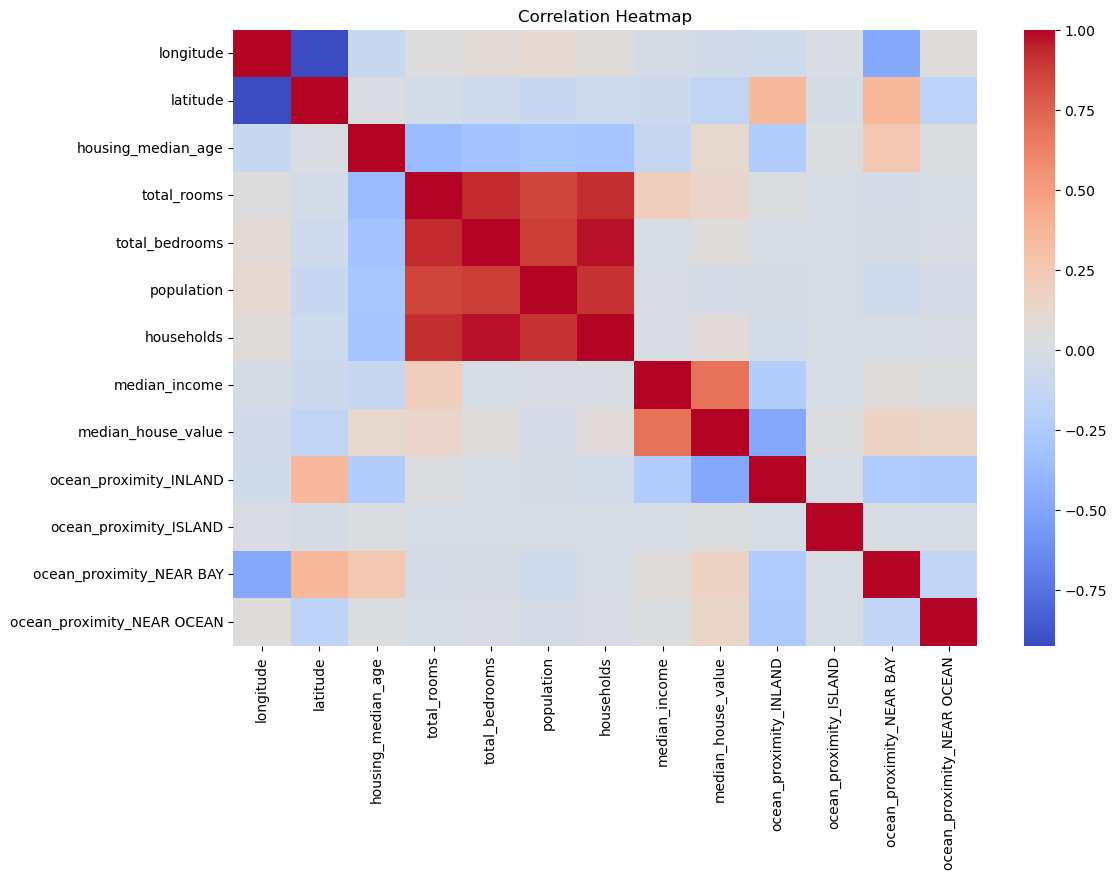


Model Performance:
Mean Squared Error (MSE): 4908041658.447792
R2 Score: 0.6254572625840542

Feature Importance:
                       Feature   Coefficient
7                median_income  75157.635752
4               total_bedrooms  42978.328403
6                   households  18425.412550
2           housing_median_age  13890.472329
9       ocean_proximity_ISLAND   2119.249166
11  ocean_proximity_NEAR OCEAN   1146.564026
10    ocean_proximity_NEAR BAY  -1616.222261
3                  total_rooms -13058.643741
8       ocean_proximity_INLAND -18538.725530
5                   population -43389.968779
0                    longitude -53713.651593
1                     latitude -54298.400415


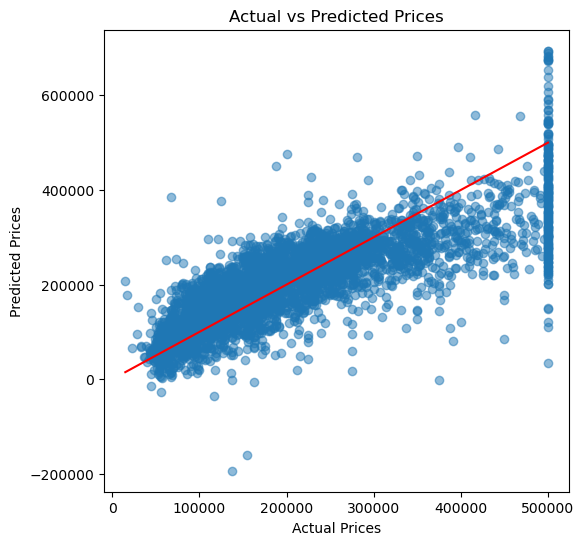


Best Alpha: 10.0

Improved Performance:
MSE: 4904383723.503915
R2 Score: 0.625736407111039


In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("housing.csv")

print("First 5 rows:\n", df.head())

print("\nDataset Info:\n")
print(df.info())

print("\nStatistical Summary:\n", df.describe())


print("\nMissing Values:\n", df.isnull().sum())


df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())


df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)


y_pred = ridge_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance:")
print(coefficients)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

# Perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')

plt.show()


ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])
ridge_cv.fit(X_train_scaled, y_train)

print("\nBest Alpha:", ridge_cv.alpha_)

# Train with best alpha
best_model = Ridge(alpha=ridge_cv.alpha_)
best_model.fit(X_train_scaled, y_train)

y_pred_best = best_model.predict(X_test_scaled)

print("\nImproved Performance:")
print("MSE:", mean_squared_error(y_test, y_pred_best))
print("R2 Score:", r2_score(y_test, y_pred_best))